# Apéndice — Convergencia y costo: estimador *next-event* vs. modo analógico

Tres campañas gemelas (homogéneo, mezcla, bicapa) que comparten escalera de
fotones, réplicas, detector y grilla angular: **lo único que cambia es el medio**,
así que toda diferencia es atribuible al *scoring* y no al montaje. Canal **co
circular** (helicidad conservada: el que tiende a $\eta(0)=2$).

Lo que responde el apéndice, en orden:

| § | pregunta | salida |
|---|---|---|
| 4 | ¿En qué se diferencian los dos modos, y coinciden una vez corregido? | $(s, A)$ + **Fig. 1** |
| 5 | ¿El perfil converge con $N$? | **Fig. 2** |
| 6 | ¿Cómo de rápido converge? | **Fig. 3**, $D_{\rm rms} \propto N^{-1/2}$ |
| 7 | ¿Cuánto cuesta cada modo? | **Fig. 4** |
| 8 | El veredicto, en números | tablas resumen y de ganancia |

**Renormalización.** El cono analógico y el del estimador no tienen exactamente
el mismo ancho, así que antes de comparar nada se ajusta
$\eta_{\rm ana}(q) \simeq 1 + A\,[\eta_{\rm est}(q/s) - 1]$ y se lleva el
analógico al marco del estimador. La corrección **re-muestrea la curva medida**,
no un ajuste suavizado: el ruido viaja con los datos y las figuras siguen
delatando que el resultado es analógico. De §5 en adelante *todo* usa el
analógico renormalizado.

**Convenios.** $q = k\,\ell^*\theta$; el central es el *pooled*
$\eta = \sum_r C_r / \sum_r I_r$; la cola se lleva a 1 restando la mediana de
$q > 0.6\,q_{\max}$; la banda es $t_{0.975,4}\,s/\sqrt{5}$ con $R = 5$ réplicas.

## 1. Configuración

In [93]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [94]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit

from utils.loaders import load_sweep
from utils.styles import apply, TEXTWIDTH_IN, COL
from utils.analysis import cbs_profiles, circular, azimuthal_average

In [95]:
# --- rutas -----------------------------------------------------------------
RESULTS = Path("/Users/niaggar/Results")
FIGDIR  = Path("figs_tesis")
FIGDIR.mkdir(exist_ok=True)

CAMPANAS = {
    "Homogeneous": "study_convergence_homogeneous_r55nm__CIRCULAR__beam2500",
    "Mixture":     "study_convergence_mixture__CIRCULAR__beam2500",
    "Bilayer":     "study_convergence_layers__CIRCULAR__beam2500",
}
MEDIOS = list(CAMPANAS)          # borrar entradas de aqui para graficar menos paneles
MODOS  = ["estimator", "analog"]

# --- fisica ----------------------------------------------------------------
N_MEDIUM   = 1.33
WAVELENGTH = 0.514                              # um
K_MEDIUM   = 2 * np.pi * N_MEDIUM / WAVELENGTH  # 1/um
SENSOR     = "farfield_cbs"

# OJO con el nombre: utils.analysis.circular define co = (S0-S3)/2 y
# cross = (S0+S3)/2. El canal fisicamente CO (helicidad conservada, el que
# lleva el cono y tiende a eta(0)=2) es el que esa funcion llama "cross".
# Ese es el que se usa en todo el cuaderno.
CANAL = "cross"

# --- binning ---------------------------------------------------------------
# La grilla nativa es dq = 0.02 (n_theta = 2000, q_max = 40). A esa resolucion
# el analogico a N bajo deja casi todos los bins vacios (36 de 2000 utiles a
# N = 1e6), asi que TODO se re-binea a una grilla comun mas gruesa. El peso es
# el angulo solido (dOmega ~ q) y el q de salida es el centroide pesado: es el
# angulo al que el modo directo realmente reporta.
DQ    = 0.02
Q_MAX = 40.0
EDGES = np.arange(0.0, Q_MAX + 1e-9, DQ)

# --- estadistica -----------------------------------------------------------
T_CRIT   = 2.776    # t_{0.975,4}, R = 5 replicas
Q_COLA   = 0.6      # fraccion de q_max que define la cola incoherente
Q_CONO   = 6.0      # ventana del cono: ajuste de renormalizacion y metricas
Q_PICO   = 0.3      # eta(0) = mediana de los bins con q < Q_PICO
SIGMA_OBJ = 1e-3    # precision objetivo en eta(0) para la proyeccion de costo

# --- estilo ----------------------------------------------------------------
apply(width_frac=1.0)
ESTILO = {"estimator": dict(color=COL[0], ls="-"),
          "analog":    dict(color=COL[2], ls="--")}
MARCA  = {"estimator": "o", "analog": "s"}
COLOR_MEDIO = {m: COL[i] for i, m in enumerate(MEDIOS)}
CMAP = plt.get_cmap("viridis")
XLIM, YLIM = (-8, 8), (0.80, 2.30)

## 2. Carga: tabla de corridas

Una fila por réplica. Todo se lee de `params_flat`, no del nombre de la carpeta.

In [96]:
sweeps = {m: load_sweep(CAMPANAS[m], base_path=RESULTS) for m in MEDIOS}

filas = []
for medio in MEDIOS:
    for key, loader in sweeps[medio].items():
        p = loader.params_flat
        if p.get("mode") not in MODOS:
            continue
        filas.append(dict(
            medium = medio,
            mode   = p["mode"],
            N      = int(p["n_photons_point_total"]),   # N del punto (suma de replicas)
            rep    = int(p["replica"]),
            key    = key,
            lstar  = float(p["lstar_angle_anchor"]),
            wall_s = float(p.get("runtime_s", np.nan)),
        ))

runs = pd.DataFrame(filas).sort_values(["medium", "mode", "N", "rep"]).reset_index(drop=True)

print(runs.groupby(["medium", "mode"]).agg(
    puntos=("N", "nunique"), corridas=("key", "size"),
    N_min=("N", "min"), N_max=("N", "max"),
    horas=("wall_s", lambda s: s.sum() / 3600)).round(2))

                       puntos  corridas    N_min       N_max  horas
medium      mode                                                   
Bilayer     analog          7        35  1000000  1000000000   4.82
            estimator       7        35     1000      500000   0.75
Homogeneous analog          7        35  1000000  1000000000   1.45
            estimator       7        35     1000      500000   0.23
Mixture     analog          7        35  1000000  1000000000   1.52
            estimator       7        35     1000      500000   2.65


## 3. Perfiles

`rebin` promedia un perfil nativo sobre la grilla gruesa pesando por
$d\Omega \propto q$; se aplica a $C$ y a $I$ **por separado** (nunca al cociente)
y a $q$ mismo, para quedarse con el centroide del bin.

Después, por cada punto de la escalera: se re-binean las 5 réplicas, se suman
los acumuladores, $\eta = \sum C / \sum I$, y se resta la mediana de la cola para
llevar el fondo a 1. Los bins que quedan sin señal se marcan `nan` (salen como
huecos en las figuras, no como un $\eta = 1$ falso).

In [97]:
def rebin(q, y):
    # Promedio de y sobre EDGES pesado por dOmega ~ q. nan si el bin quedo vacio.
    idx = np.clip(np.digitize(q, EDGES) - 1, 0, len(EDGES) - 2)
    w   = np.maximum(q, 1e-12)
    W   = np.bincount(idx, weights=w,     minlength=len(EDGES) - 1)
    S   = np.bincount(idx, weights=y * w, minlength=len(EDGES) - 1)
    return np.where(W > 0, S / np.where(W > 0, W, 1.0), np.nan)


def perfil_replica(loader, lstar):
    # (q rebineado, C, I) de UNA replica, en el canal co circular.
    pr = cbs_profiles(loader.processed_cbs(SENSOR), basis=circular,
                      time_index=0, reduce=azimuthal_average)
    q = K_MEDIUM * lstar * np.asarray(pr.theta, float)
    return (rebin(q, q),
            rebin(q, np.asarray(pr.coherent[CANAL],   float)),
            rebin(q, np.asarray(pr.incoherent[CANAL], float)))

In [98]:
filas = []
for (medio, modo, N), grp in runs.groupby(["medium", "mode", "N"]):
    lstar = float(grp["lstar"].iloc[0])

    Cs, Is = [], []
    for key in grp.sort_values("rep")["key"]:
        q, c, i = perfil_replica(sweeps[medio][key], lstar)   # q es el mismo en todas
        Cs.append(c); Is.append(i)
    C, I = np.vstack(Cs), np.vstack(Is)

    cola = q > Q_COLA * Q_MAX

    # central: pooled sobre replicas
    Cp, Ip = C.sum(0), I.sum(0)
    eta = np.where(Ip > 0, Cp / np.where(Ip > 0, Ip, 1.0), np.nan)
    eta = eta - np.nanmedian(eta[cola]) + 1.0

    # por replica: para la banda y para el ajuste de la renormalizacion
    eta_rep = np.where(I > 0, C / np.where(I > 0, I, 1.0), np.nan)
    eta_rep = eta_rep - np.nanmedian(eta_rep[:, cola], axis=1, keepdims=True) + 1.0
    err = T_CRIT * np.nanstd(eta_rep, axis=0, ddof=1) / np.sqrt(len(Cs))

    filas.append(dict(medium=medio, mode=modo, N=N, lstar=lstar,
                      q=q, eta=eta, err=err, eta_rep=eta_rep,
                      wall_s=float(grp["wall_s"].sum())))

perfiles = pd.DataFrame(filas).sort_values(["medium", "mode", "N"]).reset_index(drop=True)


def fila(medio, modo, N=None):
    # La fila de perfiles de un punto. N=None -> el N mas grande de ese modo.
    sel = perfiles[(perfiles["medium"] == medio) & (perfiles["mode"] == modo)]
    return sel.iloc[-1] if N is None else sel[sel["N"] == N].iloc[0]


def espejo(q, *ys):
    # Duplica a -q..+q; valido porque I(theta, phi) = I(theta, phi + pi).
    return (np.r_[-q[::-1], q],) + tuple(np.r_[y[::-1], y] for y in ys)


def etiqueta_N(N):
    # 500000 -> "5\times 10^{5}", para leyendas en modo matematico.
    e = int(np.floor(np.log10(N)))
    return rf"{N / 10 ** e:.0f}\times 10^{{{e}}}"


NS   = {(m, md): sorted(perfiles[(perfiles["medium"] == m) & (perfiles["mode"] == md)]["N"])
        for m in MEDIOS for md in MODOS}
NMAX = {k: v[-1] for k, v in NS.items()}

for k, v in NS.items():
    print(f"{k[0]:12s} {k[1]:9s}: N = {[f'{n:.0e}' for n in v]}")

/Users/niaggar/Developer/luminis-mc/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Homogeneous  estimator: N = ['1e+03', '3e+03', '1e+04', '3e+04', '1e+05', '3e+05', '5e+05']
Homogeneous  analog   : N = ['1e+06', '3e+06', '1e+07', '3e+07', '1e+08', '5e+08', '1e+09']
Mixture      estimator: N = ['1e+03', '3e+03', '1e+04', '3e+04', '1e+05', '3e+05', '5e+05']
Mixture      analog   : N = ['1e+06', '3e+06', '1e+07', '3e+07', '1e+08', '5e+08', '1e+09']
Bilayer      estimator: N = ['1e+03', '3e+03', '1e+04', '3e+04', '1e+05', '3e+05', '5e+05']
Bilayer      analog   : N = ['1e+06', '3e+06', '1e+07', '3e+07', '1e+08', '5e+08', '1e+09']


In [99]:
# chequeo rapido: misma grilla en q dentro de cada campana + bins sin senal
for medio in MEDIOS:
    sub = perfiles[perfiles["medium"] == medio]
    igual = all(np.allclose(sub["q"].iloc[0], q) for q in sub["q"])
    print(f"{medio:12s}: grilla q identica = {igual} | dq = {DQ} | "
          f"l* = {sub['lstar'].iloc[0]:.3f} um")
    for _, r in sub.iterrows():
        malos = int(np.isnan(r["eta"]).sum())
        if malos:
            print(f"    {r['mode']:9s} N={r['N']:>13,}: "
                  f"{malos:3d}/{r['eta'].size} bins vacios")

Homogeneous : grilla q identica = True | dq = 0.02 | l* = 39.796 um
    analog    N=    1,000,000: 472/2000 bins vacios
    analog    N=    3,000,000: 159/2000 bins vacios
    analog    N=   10,000,000:  42/2000 bins vacios
    analog    N=   30,000,000:  17/2000 bins vacios
    analog    N=  100,000,000:   4/2000 bins vacios
    analog    N=  500,000,000:   1/2000 bins vacios
    analog    N=1,000,000,000:   1/2000 bins vacios
Mixture     : grilla q identica = True | dq = 0.02 | l* = 20.412 um
    analog    N=    1,000,000: 126/2000 bins vacios
    analog    N=    3,000,000:  39/2000 bins vacios
    analog    N=   10,000,000:  14/2000 bins vacios
    analog    N=   30,000,000:   4/2000 bins vacios
    analog    N=  100,000,000:   1/2000 bins vacios
Bilayer     : grilla q identica = True | dq = 0.02 | l* = 23.217 um
    analog    N=    1,000,000: 235/2000 bins vacios
    analog    N=    3,000,000:  73/2000 bins vacios
    analog    N=   10,000,000:  24/2000 bins vacios
    analog    N=

## 4. Renormalización del analógico

Modelo de dos parámetros, ancho y amplitud:

$$\eta_{\rm ana}(q) \;=\; 1 + A\,\bigl[\eta_{\rm est}(q/s) - 1\bigr]$$

$s$ es la razón de anchos del cono (analógico / estimador) y $A$ la de
amplitudes. Se ajusta **réplica por réplica** dentro del cono ($0 < q < 6$), con
el estimador a $N_{\max}$ como referencia; el valor central es la media de las
cinco y la incertidumbre $t\,s/\sqrt{5}$.

La corrección invierte el modelo y se aplica a **todos** los $N$ del analógico
con los $(s, A)$ ajustados a $N_{\max}$:

$$\eta_{\rm ren}(q) \;=\; 1 + \frac{\eta_{\rm ana}(s\,q) - 1}{A}$$

Es un **re-muestreo de la curva medida**: cada punto sigue siendo un dato
analógico y su ruido viaja con él. La última celda de la sección lo verifica
comparando la dispersión de la cola antes y después.

In [100]:
filas = []
for medio in MEDIOS:
    r_est, r_ana = fila(medio, "estimator"), fila(medio, "analog")

    fin = np.isfinite(r_est["eta"])
    q_ref, e_ref = r_est["q"][fin], r_est["eta"][fin]

    def modelo(q, s, A):
        return 1.0 + A * np.interp(q / s, q_ref, e_ref - 1.0,
                                   left=e_ref[0] - 1.0, right=0.0)

    par = []
    for e_r in r_ana["eta_rep"]:
        ok = (r_ana["q"] > 0) & (r_ana["q"] < Q_CONO) & np.isfinite(e_r)
        p, _ = curve_fit(modelo, r_ana["q"][ok], e_r[ok], p0=[1.0, 1.0],
                         bounds=([0.3, 0.5], [3.0, 1.5]), maxfev=20000)
        par.append(p)

    par = np.vstack(par)
    (s, A), ci = par.mean(0), T_CRIT * par.std(0, ddof=1) / np.sqrt(len(par))
    filas.append(dict(medium=medio, s=s, CI_s=ci[0], A=A, CI_A=ci[1],
                      ancho_ana_sobre_est=1.0 / s))

renorm = pd.DataFrame(filas).set_index("medium")
renorm.to_csv(FIGDIR / "renorm_params.csv")
print("s < 1  ->  el cono analogico es MAS ANGOSTO que el del estimador, por 1/s")
renorm.round(4)

s < 1  ->  el cono analogico es MAS ANGOSTO que el del estimador, por 1/s


,s,CI_s,A,CI_A,ancho_ana_sobre_est
medium,,,,,
Homogeneous,0.5867,0.0731,1.0822,0.1308,1.7046
Mixture,0.8991,0.0294,0.9681,0.0183,1.1122
Bilayer,0.9009,0.1418,0.9029,0.1047,1.1100


In [101]:
def renormaliza(q, eta, s, A):
    # Lleva el analogico al marco del estimador RE-MUESTREANDO la curva ruidosa.
    ok  = np.isfinite(eta)
    out = np.full_like(eta, np.nan)
    out[ok] = 1.0 + np.interp(s * q[ok], q[ok], eta[ok] - 1.0,
                              left=eta[ok][0] - 1.0, right=0.0) / A
    return out


eta_ren, err_ren = [], []
for _, r in perfiles.iterrows():
    if r["mode"] != "analog":                      # el estimador no se toca
        eta_ren.append(r["eta"]); err_ren.append(r["err"]); continue
    s, A = renorm.loc[r["medium"], "s"], renorm.loc[r["medium"], "A"]
    rep = np.vstack([renormaliza(r["q"], e, s, A) for e in r["eta_rep"]])
    eta_ren.append(renormaliza(r["q"], r["eta"], s, A))
    err_ren.append(T_CRIT * np.nanstd(rep, axis=0, ddof=1) / np.sqrt(rep.shape[0]))

perfiles["eta_ren"] = eta_ren
perfiles["err_ren"] = err_ren

# control: el ruido NO se suaviza. La dispersion en la cola queda igual salvo
# el factor 1/A que introduce la correccion de amplitud.
for medio in MEDIOS:
    r = fila(medio, "analog")
    cola = r["q"] > Q_COLA * Q_MAX
    A = renorm.loc[medio, "A"]
    print(f"{medio:12s}: sigma cola  antes = {np.nanstd(r['eta'][cola]):.4f}   "
          f"despues = {np.nanstd(r['eta_ren'][cola]):.4f}   "
          f"(esperado = {np.nanstd(r['eta'][cola]) / A:.4f})")

Homogeneous : sigma cola  antes = 0.0121   despues = 0.0117   (esperado = 0.0112)
Mixture     : sigma cola  antes = 0.0065   despues = 0.0061   (esperado = 0.0067)
Bilayer     : sigma cola  antes = 0.0081   despues = 0.0077   (esperado = 0.0090)


/Users/niaggar/Developer/luminis-mc/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


### Fig. 1 — qué corrige la renormalización

Izquierda los datos crudos, derecha renormalizados; abajo el residuo
$\Delta\eta = \eta_{\rm est} - \eta_{\rm ana}$ contra la banda combinada. Es la
figura que justifica el paso: sin ella el residuo del caso homogéneo se sale de
la banda en casi todo el cono.

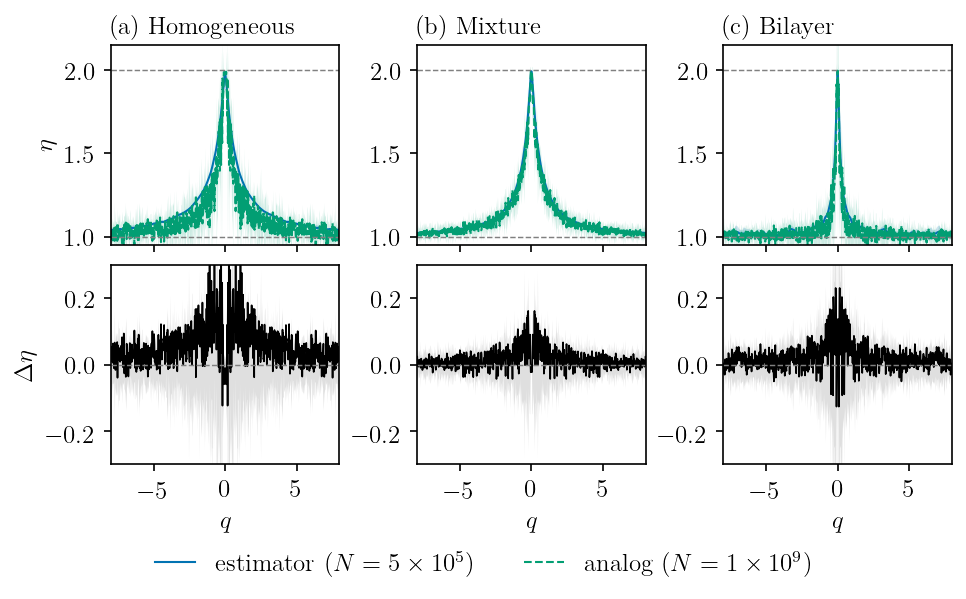

,rms_delta,max_abs_delta,frac_fuera_banda
medium,,,
Homogeneous,0.0925,0.3227,0.2148
Mixture,0.0356,0.1611,0.0635
Bilayer,0.0498,0.2301,0.0468


In [102]:
def figura_comparacion(col_eta, col_err, nombre, etiqueta_ana="analog"):
    fig, axes = plt.subplots(2, len(MEDIOS), squeeze=False,
                             figsize=(TEXTWIDTH_IN, 0.62 * TEXTWIDTH_IN),
                             sharex=True)
    tags, resumen = iter("abcdef"), []

    for j, medio in enumerate(MEDIOS):
        arriba, abajo = axes[0, j], axes[1, j]
        r = {modo: fila(medio, modo) for modo in MODOS}

        for modo in MODOS:
            q, e, h = r[modo]["q"], r[modo][col_eta], r[modo][col_err]
            lab = (etiqueta_ana if modo == "analog" else modo) + \
                  rf" ($N = {etiqueta_N(r[modo]['N'])}$)"
            qs, es, hs = espejo(q, e, h)
            arriba.plot(qs, es, lw=1.0, label=lab, **ESTILO[modo])
            arriba.fill_between(qs, es - hs, es + hs, lw=0, alpha=0.20,
                                color=ESTILO[modo]["color"])

        # residuo, evaluado sobre la grilla del estimador
        q  = r["estimator"]["q"]
        ok = np.isfinite(r["analog"][col_eta])
        e_ana = np.interp(q, r["analog"]["q"][ok], r["analog"][col_eta][ok])
        h_ana = np.interp(q, r["analog"]["q"][ok], r["analog"][col_err][ok])
        delta = r["estimator"][col_eta] - e_ana
        hcomb = np.hypot(r["estimator"][col_err], h_ana)

        qs, ds, hs = espejo(q, delta, hcomb)
        abajo.plot(qs, ds, "k-", lw=0.8)
        abajo.fill_between(qs, -hs, hs, color="gray", alpha=0.25, lw=0)
        abajo.axhline(0.0, ls="--", c="gray", lw=0.7)
        abajo.set_ylim(-0.30, 0.30)
        abajo.set_xlabel(r"$q$")

        arriba.axhline(1.0, ls="--", c="gray", lw=0.7)
        arriba.axhline(2.0, ls="--", c="gray", lw=0.7)
        arriba.set_title(rf"({next(tags)}) {medio}", loc="left")
        arriba.set_xlim(*XLIM); arriba.set_ylim(0.95, 2.15)
        arriba.grid(False); abajo.grid(False)

        cono = (q > 0) & (q < Q_CONO) & np.isfinite(delta) & (hcomb > 0)
        z = np.abs(delta[cono]) / hcomb[cono]
        resumen.append(dict(medium=medio,
                            rms_delta=np.sqrt(np.mean(delta[cono] ** 2)),
                            max_abs_delta=np.max(np.abs(delta[cono])),
                            frac_fuera_banda=np.mean(z > 1.0)))

    axes[0, 0].set_ylabel(r"$\eta$")
    axes[1, 0].set_ylabel(r"$\Delta\eta$")
    fig.legend(*axes[0, 0].get_legend_handles_labels(), ncol=2,
               loc="outside lower center", frameon=False, handlelength=1.6)
    fig.savefig(FIGDIR / nombre)
    plt.show()
    return pd.DataFrame(resumen).set_index("medium")


resumen_crudo = figura_comparacion("eta", "err", "f1a_est_vs_ana_crudo.pdf")
resumen_crudo.round(4)

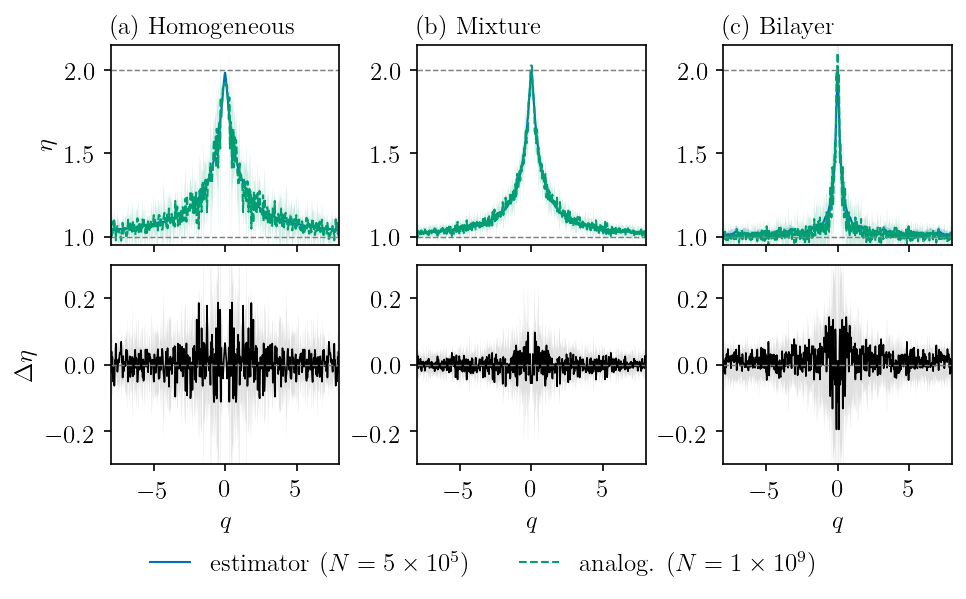

,rms_delta,max_abs_delta,frac_fuera_banda
medium,,,
Homogeneous,0.0451,0.1863,0.0537
Mixture,0.0223,0.0965,0.0435
Bilayer,0.0405,0.1950,0.0736


In [103]:
resumen_ren = figura_comparacion("eta_ren", "err_ren", "f1b_est_vs_ana_renorm.pdf",
                                 etiqueta_ana="analog.")
resumen_ren.round(4)

In [104]:
# antes vs despues, en una sola tabla
tabla_renorm = (resumen_crudo[["rms_delta", "frac_fuera_banda"]]
                .join(resumen_ren[["rms_delta", "frac_fuera_banda"]],
                      lsuffix="_crudo", rsuffix="_renorm")
                .join(renorm[["s", "CI_s", "A", "CI_A"]]))
tabla_renorm.to_csv(FIGDIR / "tabla_renorm.csv")
tabla_renorm.round(4)

,rms_delta_crudo,frac_fuera_banda_crudo,rms_delta_renorm,frac_fuera_banda_renorm,s,CI_s,A,CI_A
medium,,,,,,,,
Homogeneous,0.0925,0.2148,0.0451,0.0537,0.5867,0.0731,1.0822,0.1308
Mixture,0.0356,0.0635,0.0223,0.0435,0.8991,0.0294,0.9681,0.0183
Bilayer,0.0498,0.0468,0.0405,0.0736,0.9009,0.1418,0.9029,0.1047


## 5. Fig. 2 — convergencia del perfil con $N$

Una fila por modo, una columna por medio. El color codifica $N$ —con **una barra
por fila**, porque las dos escaleras no se solapan: el estimador va de $10^3$ a
$5\times10^5$ y el analógico de $10^6$ a $10^9$— y la curva negra es la corrida
más grande de ese mismo modo. Se lee de un vistazo dónde la escalera ya se pegó a
la referencia y dónde el ruido todavía manda.

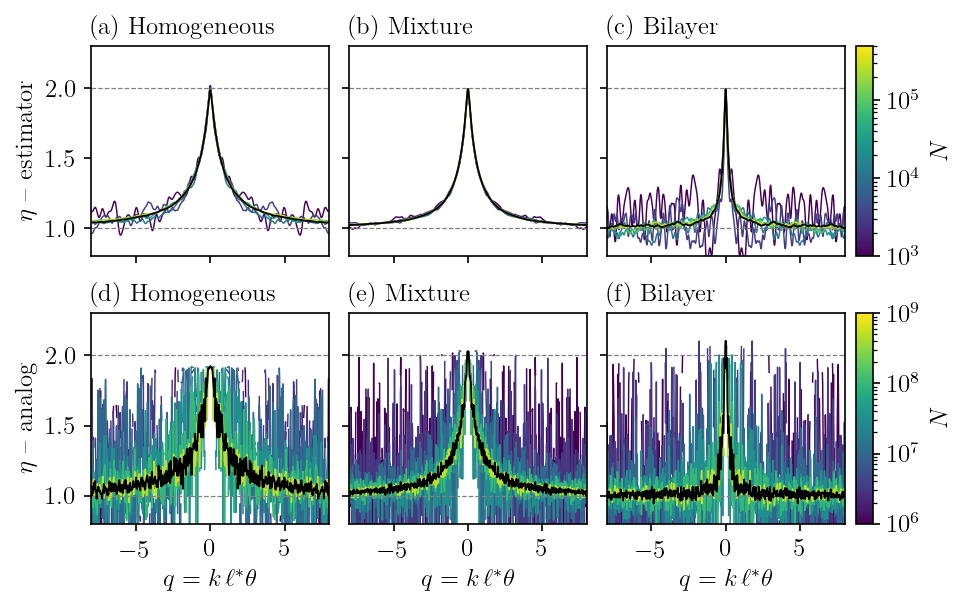

In [105]:
def figura_convergencia(col_eta, nombre):
    fig, axes = plt.subplots(len(MODOS), len(MEDIOS), squeeze=False,
                             figsize=(TEXTWIDTH_IN, 0.62 * TEXTWIDTH_IN),
                             sharex=True, sharey=True)
    tags = iter("abcdef")

    for i, modo in enumerate(MODOS):
        # una escala de color POR MODO: las dos escaleras no se solapan en N,
        # con una sola todas las curvas del estimador saldrian del mismo color.
        todos_N = sorted({n for m in MEDIOS for n in NS[(m, modo)]})
        norm = LogNorm(vmin=todos_N[0], vmax=todos_N[-1])

        for j, medio in enumerate(MEDIOS):
            ax = axes[i, j]
            for N in NS[(medio, modo)]:
                r = fila(medio, modo, N)
                ax.plot(*espejo(r["q"], r[col_eta]), color=CMAP(norm(N)), lw=0.7)
            r = fila(medio, modo)                       # referencia del propio modo
            ax.plot(*espejo(r["q"], r[col_eta]), color="k", lw=0.9, zorder=5)

            ax.axhline(1.0, ls="--", c="gray", lw=0.6)
            ax.axhline(2.0, ls="--", c="gray", lw=0.6)
            ax.set_title(rf"({next(tags)}) {medio}", loc="left")
            ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.grid(False)

        axes[i, 0].set_ylabel(rf"$\eta$ -- {modo}")
        cb = fig.colorbar(ScalarMappable(norm=norm, cmap=CMAP),
                          ax=axes[i, :].tolist(), pad=0.015, aspect=12)
        cb.set_label(r"$N$")

    for ax in axes[-1]:
        ax.set_xlabel(r"$q = k\,\ell^*\theta$")

    fig.savefig(FIGDIR / nombre)
    plt.show()


figura_convergencia("eta_ren", "f2_convergencia_perfil.pdf")

## 6. Fig. 3 — convergencia cuantitativa

$$D_{\rm rms}(N) \;=\; \bigl\langle (\eta_N - \eta_{\rm ref})^2 \bigr\rangle^{1/2}
\quad \text{sobre } q < 6$$

con $\eta_{\rm ref}$ la referencia del **propio** modo a $N_{\max}$ (el último
punto queda fuera: es cero por construcción). La guía gris es $N^{-1/2}$ anclada
al primer punto; la pendiente ajustada de cada serie va en la tabla.

La línea punteada negra es el **piso sistemático**: el $D_{\rm rms}$ entre las
dos referencias. Bajar de ahí ya no es ganar estadística, es medir la diferencia
residual entre modos.

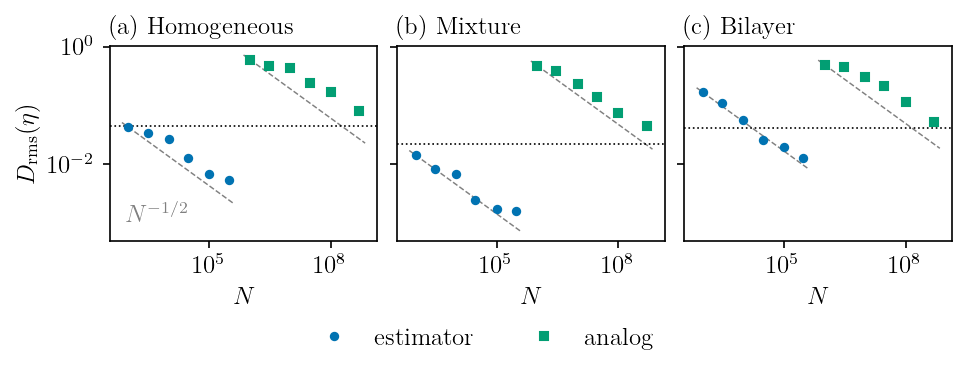

pendiente
medium      mode                
Homogeneous estimator     -0.398
            analog        -0.325
Mixture     estimator     -0.414
            analog        -0.404
Bilayer     estimator     -0.469
            analog        -0.373

In [106]:
def d_rms(q, a, b):
    ok = (q < Q_CONO) & np.isfinite(a) & np.isfinite(b)
    return float(np.sqrt(np.mean((a[ok] - b[ok]) ** 2)))


fig, axes = plt.subplots(1, len(MEDIOS), squeeze=False, sharey=True,
                         figsize=(TEXTWIDTH_IN, 0.38 * TEXTWIDTH_IN))
axes, tags, filas = axes[0], iter("abc"), []

for ax, medio in zip(axes, MEDIOS):
    for modo in MODOS:
        ref = fila(medio, modo)
        ns  = NS[(medio, modo)][:-1]
        D   = np.array([d_rms(ref["q"], fila(medio, modo, n)["eta_ren"],
                              ref["eta_ren"]) for n in ns])
        ax.plot(ns, D, ls="none", ms=3.5, marker=MARCA[modo],
                color=ESTILO[modo]["color"], label=modo)

        guia = np.array([ns[0] * 0.7, ns[-1] * 1.4])
        ax.plot(guia, D[0] * (guia / ns[0]) ** -0.5, "--", c="gray", lw=0.7, zorder=0)
        filas.append(dict(medium=medio, mode=modo,
                          pendiente=np.polyfit(np.log(ns), np.log(D), 1)[0]))

    piso = d_rms(fila(medio, "estimator")["q"],
                 fila(medio, "estimator")["eta_ren"],
                 fila(medio, "analog")["eta_ren"])
    ax.axhline(piso, ls=":", c="k", lw=0.8, zorder=0)

    ax.set(xscale="log", yscale="log", xlabel=r"$N$")
    ax.set_title(rf"({next(tags)}) {medio}", loc="left")
    ax.grid(False)

axes[0].set_ylabel(r"$D_{\mathrm{rms}}(\eta)$")
axes[0].annotate(r"$N^{-1/2}$", (0.06, 0.10), xycoords="axes fraction", color="gray")
fig.legend(*axes[0].get_legend_handles_labels(), ncol=2, loc="outside lower center",
           frameon=False, handlelength=1.6)
fig.savefig(FIGDIR / "f3_convergencia_rms.pdf")
plt.show()

pendientes = pd.DataFrame(filas).set_index(["medium", "mode"])
pendientes.round(3)

## 7. Fig. 4 — costo

- **(a)** $T_{\rm wall}$ del punto completo (suma de las 5 réplicas) vs. $N$. El
  analógico es una recta de pendiente $+1$ perfecta. El estimador se despega de
  la guía a $N$ bajo: cada réplica paga un **setup fijo** (tabulación de la
  función de fase + arranque de los 46 hilos) que a $N=10^3$ es todo el tiempo de
  la corrida; de $N \gtrsim 10^5$ en adelante la pendiente se recupera. Por eso
  los escalares de costo se citan siempre en $N_{\max}$, no promediados sobre la
  escalera.
- **(b)** $\sigma[\eta(0)]$ vs. tiempo: la comparación **a igual costo**, que es
  la pregunta operativa. Fijado un presupuesto de CPU, la serie que quede más
  abajo es la que conviene. La guía gris es $T^{-1/2}$.

$\sigma[\eta(0)]$ es la del punto completo ($s/\sqrt{R}$, no la dispersión de una
réplica suelta), con $\eta(0)$ leído como la mediana de los bins con $q < 0.3$ —
o sea un ápice promediado sobre los tres primeros bins, que por eso sale por
debajo del 2 teórico: con $dq = 0.1$ el pico no se resuelve, y el número sólo
tiene sentido **comparado entre modos**, no contra la cota de reciprocidad.

In [107]:
def pico(q, eta):
    # eta(0): mediana de los bins del apice, inmune a un bin ruidoso suelto.
    return float(np.nanmedian(eta[q < Q_PICO]))


# escalares por punto de la escalera
filas = []
for _, r in perfiles.iterrows():
    e0_rep = np.array([pico(r["q"], e) for e in r["eta_rep"]])
    if r["mode"] == "analog":                       # el apice tambien se renormaliza
        e0_rep = 1.0 + (e0_rep - 1.0) / renorm.loc[r["medium"], "A"]
    sigma = float(np.nanstd(e0_rep, ddof=1) / np.sqrt(e0_rep.size))
    filas.append(dict(medium=r["medium"], mode=r["mode"], N=r["N"],
                      eta0=pico(r["q"], r["eta_ren"]), sigma_eta0=sigma,
                      T_wall=r["wall_s"], fotones_s=r["N"] / r["wall_s"],
                      FOM=1.0 / (sigma ** 2 * r["wall_s"])))

costo = pd.DataFrame(filas)

/var/folders/hl/qm9fczw178qg19fkz2_x7sqr0000gn/T/ipykernel_13406/1120119922.py:3: RuntimeWarning: All-NaN slice encountered
  return float(np.nanmedian(eta[q < Q_PICO]))
/Users/niaggar/Developer/luminis-mc/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


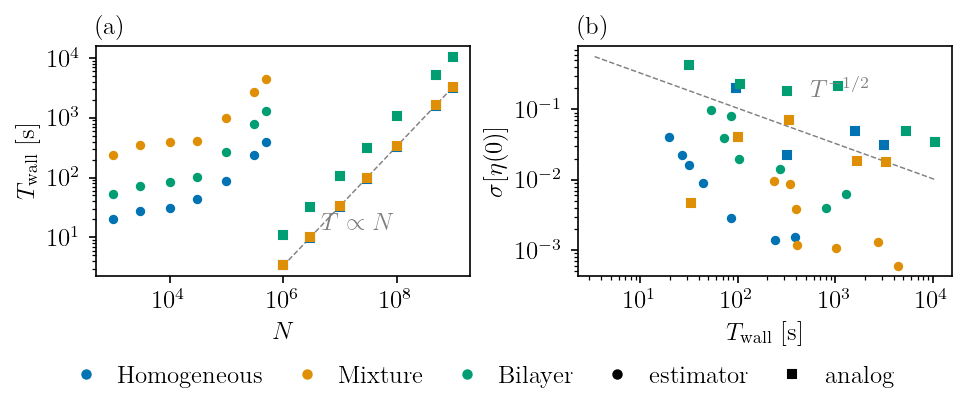

In [108]:
fig, (a, b) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.42 * TEXTWIDTH_IN))

for medio in MEDIOS:
    for modo in MODOS:
        d = costo[(costo["medium"] == medio) & (costo["mode"] == modo)].sort_values("N")
        kw = dict(ls="none", ms=3.5, marker=MARCA[modo], color=COLOR_MEDIO[medio])
        a.plot(d["N"],      d["T_wall"],     **kw)
        b.plot(d["T_wall"], d["sigma_eta0"], **kw)

# guias ancladas al analogico (el modo que si es lineal en todo su rango) y
# dibujadas SOLO sobre ese rango, para no estirar los ejes hacia zonas vacias
ana = costo[costo["mode"] == "analog"].sort_values("N")
ref = ana.iloc[-1]
gN = np.array([ana["N"].min(), ana["N"].max()])
gT = np.array([ana["T_wall"].min(), ana["T_wall"].max()])
a.plot(gN, ref["T_wall"] * gN / ref["N"], "--", c="gray", lw=0.7, zorder=0)
b.plot(gT, ref["sigma_eta0"] * (gT / ref["T_wall"]) ** -0.5, "--", c="gray", lw=0.7, zorder=0)

a.set(xscale="log", yscale="log", xlabel=r"$N$", ylabel=r"$T_{\mathrm{wall}}$ [s]")
a.set_title("(a)", loc="left")
a.annotate(r"$T \propto N$", (0.60, 0.20), xycoords="axes fraction", color="gray")

b.set(xscale="log", yscale="log", xlabel=r"$T_{\mathrm{wall}}$ [s]",
      ylabel=r"$\sigma[\eta(0)]$")
b.set_title("(b)", loc="left")
b.annotate(r"$T^{-1/2}$", (0.62, 0.78), xycoords="axes fraction", color="gray")

for ax in (a, b):
    ax.grid(False)

# leyenda factorizada: el color dice el medio, el simbolo dice el modo
marcas = [Line2D([], [], ls="none", marker="o", color=COLOR_MEDIO[m], label=m)
          for m in MEDIOS]
marcas += [Line2D([], [], ls="none", marker=MARCA[md], color="k", label=md)
           for md in MODOS]
fig.legend(handles=marcas, ncol=len(marcas), loc="outside lower center",
           frameon=False, handlelength=1.0, columnspacing=1.2)
fig.savefig(FIGDIR / "f4_costo.pdf")
plt.show()

## 8. Tabla resumen

Una fila por (medio, modo) con la corrida convergida: el ápice y su intervalo, el
ancho del cono a media altura, el costo y la figura de mérito

$$\mathrm{FOM} \;=\; \frac{1}{\sigma^2[\eta(0)]\;T_{\rm wall}}$$

que es el ruido que compra un segundo de CPU, independiente de $N$ mientras
$\sigma^2 \propto 1/N$ y $T \propto N$. Se cita en $N_{\max}$, donde las dos
condiciones se cumplen.

Debajo, el veredicto operativo: la ganancia $\mathrm{FOM}_{\rm est} /
\mathrm{FOM}_{\rm ana}$ y el tiempo que costaría llegar a
$\sigma[\eta(0)] = 10^{-3}$ en cada modo, $T = 1/(\mathrm{FOM}\,\sigma^2)$.

In [109]:
def fwhm(q, eta):
    # Ancho total a media altura, respecto al fondo incoherente (= 1).
    mitad = 1.0 + 0.5 * (pico(q, eta) - 1.0)
    i = int(np.argmax(eta < mitad))
    if i == 0:
        return np.nan
    return 2.0 * float(np.interp(mitad, [eta[i], eta[i - 1]], [q[i], q[i - 1]]))


filas = []
for medio in MEDIOS:
    for modo in MODOS:
        r = fila(medio, modo)
        d = costo[(costo["medium"] == medio) & (costo["mode"] == modo)
                  & (costo["N"] == r["N"])].iloc[0]
        filas.append({
            "medium":        medio,
            "mode":          modo,
            "N_max":         r["N"],
            "eta(0)":        d["eta0"],
            "CI_eta(0)":     T_CRIT * d["sigma_eta0"],
            "dq_FWHM":       fwhm(r["q"], r["eta_ren"]),
            "T_wall [h]":    d["T_wall"] / 3600,
            "fotones/s":     d["fotones_s"],
            "sigma_eta0":    d["sigma_eta0"],
            "FOM [1/s]":     d["FOM"],
        })

resumen = pd.DataFrame(filas).set_index(["medium", "mode"])
resumen.to_csv(FIGDIR / "tabla_resumen.csv")
resumen.round(4)

N_max  eta(0)  CI_eta(0)  dq_FWHM  T_wall [h]  \
medium      mode                                                            
Homogeneous estimator      500000  1.8664     0.0042   1.7134      0.1081   
            analog     1000000000  1.8923     0.0860   0.9493      0.8828   
Mixture     estimator      500000  1.8423     0.0017   1.3526      1.2253   
            analog     1000000000  1.8444     0.0499   1.2975      0.9225   
Bilayer     estimator      500000  1.6003     0.0176   0.6876      0.3624   
            analog     1000000000  1.5684     0.0941   0.5943      2.9303   

                         fotones/s  sigma_eta0  FOM [1/s]  
medium      mode                                           
Homogeneous estimator    1284.9805      0.0015  1098.6694  
            analog     314655.4046      0.0310     0.3276  
Mixture     estimator     113.3538      0.0006   632.1075  
            analog     301115.7782      0.0180     0.9323  
Bilayer     estimator     383.2912      0.0063    19.1184  
            analog      94794.2301      0.0339     0.0825

In [110]:
fom = resumen["FOM [1/s]"].unstack()
veredicto = pd.DataFrame({"ganancia_FOM": fom["estimator"] / fom["analog"]})
for modo in MODOS:
    # T necesario para SIGMA_OBJ, extrapolando con FOM constante
    veredicto[f"T_{modo} [h]"] = 1.0 / (fom[modo] * SIGMA_OBJ ** 2) / 3600
veredicto = veredicto.loc[MEDIOS]
veredicto.to_csv(FIGDIR / "tabla_veredicto.csv")

print(f"ganancia = FOM_est / FOM_ana en N_max;  T = tiempo para sigma[eta(0)] = {SIGMA_OBJ:g}")
veredicto.round(2)

ganancia = FOM_est / FOM_ana en N_max;  T = tiempo para sigma[eta(0)] = 0.001


,ganancia_FOM,T_estimator [h],T_analog [h]
medium,,,
Homogeneous,3353.80,0.25,847.95
Mixture,677.98,0.44,297.94
Bilayer,231.77,14.53,3367.41


## 9. Qué queda guardado

En `figs_tesis/`:

| archivo | qué es |
|---|---|
| `f1a_est_vs_ana_crudo.pdf` | Fig. 1a — los dos modos sin renormalizar |
| `f1b_est_vs_ana_renorm.pdf` | Fig. 1b — con el analógico renormalizado |
| `f2_convergencia_perfil.pdf` | Fig. 2 — convergencia del perfil con $N$ |
| `f3_convergencia_rms.pdf` | Fig. 3 — $D_{\rm rms}(N)$ y el piso sistemático |
| `f4_costo.pdf` | Fig. 4 — $T(N)$, $\sigma$ vs. costo y FOM |
| `renorm_params.csv`, `tabla_renorm.csv` | $s$, $A$ y el residuo antes/después |
| `tabla_resumen.csv`, `tabla_veredicto.csv` | escalares convergidos, ganancia y speedup |

**Perillas.** `DQ` cambia la resolución de todas las figuras; `Q_CONO` la ventana
del ajuste y de las métricas; `MEDIOS` cuántas columnas salen; `CANAL` el canal de
polarización; `SIGMA_OBJ` el objetivo de la proyección de costo.

**Antes de citar números:** que las tres campañas compartan `n_theta` y
`n_threads` (si no, las FOM no son comparables entre medios), y que la pendiente
de $D_{\rm rms}$ esté cerca de $-1/2$ en las dos series.